In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------
# Hypothetical LoD settings
# -------------------------
data_quality_levels = ["Low data quality", "Medium data quality", "High data quality"]
complexity_levels = ["Normal complexity", "Higher complexity 1", "Higher complexity 2"]

ecm_types = [
    "Heating setpoint ECM",
    "Occupancy ventilation ECM",
]

rows = []

rng = np.random.default_rng(42)

for ecm in ecm_types:
    for dq_i, dq in enumerate(data_quality_levels):
        for cx_i, cx in enumerate(complexity_levels):

            # Hypothesis A:
            # Heating setpoint ECM is mainly affected by heating-schedule LoD.
            if ecm == "Heating setpoint ECM":
                median_saving = 12 + dq_i * 2.5 + cx_i * 0.5
                uncertainty_width = 8 - dq_i * 2.0 + cx_i * 0.8

            # Hypothesis B:
            # Occupancy ventilation ECM is mainly affected by IHG/occupancy schedule LoD.
            else:
                median_saving = 8 + dq_i * 3.0 + cx_i * 1.0
                uncertainty_width = 10 - dq_i * 2.5 + cx_i * 1.0

            p05 = median_saving - uncertainty_width / 2
            p95 = median_saving + uncertainty_width / 2

            rows.append({
                "ecm": ecm,
                "data_quality": dq,
                "complexity": cx,
                "median_saving_pct": median_saving,
                "p05_saving_pct": p05,
                "p95_saving_pct": p95,
                "uncertainty_width": p95 - p05,
            })

hyp_df = pd.DataFrame(rows)

hyp_df

,ecm,data_quality,complexity,median_saving_pct,p05_saving_pct,p95_saving_pct,uncertainty_width
0,Heating setpoint ECM,Low data quality,Normal complexity,12.0,8.00,16.00,8.0
1,Heating setpoint ECM,Low data quality,Higher complexity 1,12.5,8.10,16.90,8.8
2,Heating setpoint ECM,Low data quality,Higher complexity 2,13.0,8.20,17.80,9.6
3,Heating setpoint ECM,Medium data quality,Normal complexity,14.5,11.50,17.50,6.0
4,Heating setpoint ECM,Medium data quality,Higher complexity 1,15.0,11.60,18.40,6.8
5,Heating setpoint ECM,Medium data quality,Higher complexity 2,15.5,11.70,19.30,7.6
6,Heating setpoint ECM,High data quality,Normal complexity,17.0,15.00,19.00,4.0
7,Heating setpoint ECM,High data quality,Higher complexity 1,17.5,15.10,19.90,4.8
8,Heating setpoint ECM,High data quality,Higher complexity 2,18.0,15.20,20.80,5.6
9,Occupancy ventilation ECM,Low data quality,Normal complexity,8.0,3.00,13.00,10.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_lod_hypothesis_data():
    """
    Create illustrative LoD-design data for two ECM types and two hypotheses.

    This is conceptual data for research-design illustration, not model output.
    """

    data_quality_levels = [1, 2, 3]
    complexity_levels = [1, 2, 3]

    rows = []

    for dq in data_quality_levels:
        for cx in complexity_levels:

            # -------------------------
            # Hypothesis 1:
            # Heating schedule LoD mainly affects heating setpoint ECM
            # -------------------------

            # Heating setpoint ECM:
            # higher data quality reduces uncertainty strongly;
            # complexity helps slightly only when data quality is high.
            median_saving_h1_setpoint = 8 + 2.0 * dq + 0.5 * cx
            uncertainty_h1_setpoint = 14 - 3.0 * dq - 0.8 * cx
            uncertainty_h1_setpoint = max(2.0, uncertainty_h1_setpoint)

            rows.append({
                "hypothesis": "H1: heating-schedule LoD matters for setpoint ECM",
                "ecm_type": "Heating setpoint ECM",
                "data_quality": dq,
                "complexity": cx,
                "median_saving_pct": median_saving_h1_setpoint,
                "uncertainty_width_pct": uncertainty_h1_setpoint,
            })

            # Occupancy ventilation ECM:
            # heating schedule LoD has weaker effect.
            median_saving_h1_occ = 6 + 0.4 * dq + 0.3 * cx
            uncertainty_h1_occ = 8 - 0.5 * dq - 0.4 * cx
            uncertainty_h1_occ = max(4.0, uncertainty_h1_occ)

            rows.append({
                "hypothesis": "H1: heating-schedule LoD matters for setpoint ECM",
                "ecm_type": "Occupancy ventilation ECM",
                "data_quality": dq,
                "complexity": cx,
                "median_saving_pct": median_saving_h1_occ,
                "uncertainty_width_pct": uncertainty_h1_occ,
            })

            # -------------------------
            # Hypothesis 2:
            # IHG/occupancy LoD mainly affects occupancy ventilation ECM
            # -------------------------

            # Heating setpoint ECM:
            # IHG schedule LoD has limited effect.
            median_saving_h2_setpoint = 10 + 0.5 * dq + 0.3 * cx
            uncertainty_h2_setpoint = 7 - 0.5 * dq - 0.3 * cx
            uncertainty_h2_setpoint = max(3.0, uncertainty_h2_setpoint)

            rows.append({
                "hypothesis": "H2: IHG/occupancy LoD matters for ventilation ECM",
                "ecm_type": "Heating setpoint ECM",
                "data_quality": dq,
                "complexity": cx,
                "median_saving_pct": median_saving_h2_setpoint,
                "uncertainty_width_pct": uncertainty_h2_setpoint,
            })

            # Occupancy ventilation ECM:
            # higher IHG/occupancy data quality strongly reduces uncertainty;
            # complexity helps only when data quality is sufficient.
            median_saving_h2_occ = 5 + 1.5 * dq + 0.7 * cx
            uncertainty_h2_occ = 15 - 3.5 * dq - 0.9 * cx
            uncertainty_h2_occ = max(2.0, uncertainty_h2_occ)

            rows.append({
                "hypothesis": "H2: IHG/occupancy LoD matters for ventilation ECM",
                "ecm_type": "Occupancy ventilation ECM",
                "data_quality": dq,
                "complexity": cx,
                "median_saving_pct": median_saving_h2_occ,
                "uncertainty_width_pct": uncertainty_h2_occ,
            })

    return pd.DataFrame(rows)


hypothesis_df = make_lod_hypothesis_data()
hypothesis_df.head()

,hypothesis,ecm_type,data_quality,complexity,median_saving_pct,uncertainty_width_pct
0,H1: heating-schedule LoD matters for setpoint ECM,Heating setpoint ECM,1,1,10.5,10.2
1,H1: heating-schedule LoD matters for setpoint ECM,Occupancy ventilation ECM,1,1,6.7,7.1
2,H2: IHG/occupancy LoD matters for ventilation ECM,Heating setpoint ECM,1,1,10.8,6.2
3,H2: IHG/occupancy LoD matters for ventilation ECM,Occupancy ventilation ECM,1,1,7.2,10.6
4,H1: heating-schedule LoD matters for setpoint ECM,Heating setpoint ECM,1,2,11.0,9.4


In [19]:
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.labelsize": 18,
    "legend.fontsize": 12,
})

In [23]:
ihg_lods = [
    r"ihg$_{1}^{1}$",
    r"ihg$_{1}^{2}$",
    r"ihg$_{1}^{3}$",
    r"ihg$_{2}^{3}$",
    r"ihg$_{3}^{3}$",
]

om_lods = [
    r"O&M$_{1}^{1}$",
    r"O&M$_{1}^{2}$",
    r"O&M$_{1}^{3}$",
    r"O&M$_{2}^{3}$",
    r"O&M$_{3}^{3}$",
]

In [24]:
def make_ecm_lod_hypothesis_data(ihg_lods, om_lods):
    """
    Create illustrative LoD-effect data for two ECMs.

    ECM-1:
        Heating setpoint change.
        Hypothesis: O&M / heating-operation schedule LoD matters more.

    ECM-2:
        Occupancy-based ventilation control.
        Hypothesis: IHG / occupancy schedule LoD matters more.

    This is conceptual data for hypothesis illustration, not simulation output.
    """

    rows = []

    for i, ihg in enumerate(ihg_lods, start=1):
        for j, om in enumerate(om_lods, start=1):

            # -------------------------
            # ECM-1: heating setpoint change
            # More sensitive to O&M/heating schedule LoD
            # -------------------------
            ecm1_median_saving = 6.0 + 0.4 * i + 1.4 * j
            ecm1_uncertainty = 14.0 - 0.6 * i - 2.0 * j
            ecm1_uncertainty = max(ecm1_uncertainty, 2.0)

            rows.append({
                "ecm": "ECM-1: Heating setpoint change",
                "ihg_lod": ihg,
                "om_lod": om,
                "ihg_level": i,
                "om_level": j,
                "median_saving_pct": ecm1_median_saving,
                "uncertainty_width_pct": ecm1_uncertainty,
            })

            # -------------------------
            # ECM-2: occupancy-based ventilation control
            # More sensitive to IHG / occupancy schedule LoD
            # -------------------------
            ecm2_median_saving = 5.0 + 1.5 * i + 0.4 * j
            ecm2_uncertainty = 15.0 - 2.2 * i - 0.5 * j
            ecm2_uncertainty = max(ecm2_uncertainty, 2.0)

            rows.append({
                "ecm": "ECM-2: Occupancy-based ventilation control",
                "ihg_lod": ihg,
                "om_lod": om,
                "ihg_level": i,
                "om_level": j,
                "median_saving_pct": ecm2_median_saving,
                "uncertainty_width_pct": ecm2_uncertainty,
            })

    return pd.DataFrame(rows)


lod_hypothesis_df = make_ecm_lod_hypothesis_data(
    ihg_lods=ihg_lods,
    om_lods=om_lods,
)

lod_hypothesis_df.head()

,ecm,ihg_lod,om_lod,ihg_level,om_level,median_saving_pct,uncertainty_width_pct
0,ECM-1: Heating setpoint change,ihg$_{1}^{1}$,O&M$_{1}^{1}$,1,1,7.8,11.4
1,ECM-2: Occupancy-based ventilation control,ihg$_{1}^{1}$,O&M$_{1}^{1}$,1,1,6.9,12.3
2,ECM-1: Heating setpoint change,ihg$_{1}^{1}$,O&M$_{1}^{2}$,1,2,9.2,9.4
3,ECM-2: Occupancy-based ventilation control,ihg$_{1}^{1}$,O&M$_{1}^{2}$,1,2,7.3,11.8
4,ECM-1: Heating setpoint change,ihg$_{1}^{1}$,O&M$_{1}^{3}$,1,3,10.6,7.4


In [25]:
def plot_ecm_lod_design_space(
    df,
    ecm_name,
    ihg_lods,
    om_lods,
    title=None,
    save_path=None,
):
    """
    Plot ECM evaluation outcome over IHG LoD and O&M LoD design space.

    x-axis:
        IHG schedule LoD

    y-axis:
        O&M / heating-operation schedule LoD

    point size:
        uncertainty width

    point label:
        median ECM saving
    """

    plot_df = df[df["ecm"] == ecm_name].copy()

    if title is None:
        title = ecm_name

    fig, ax = plt.subplots(figsize=(7, 6))

    sizes = 90 + plot_df["uncertainty_width_pct"] * 35

    sc = ax.scatter(
        plot_df["ihg_level"],
        plot_df["om_level"],
        s=sizes,
        c=plot_df["median_saving_pct"],
        alpha=0.65,
    )

    for _, row in plot_df.iterrows():
        ax.text(
            row["ihg_level"],
            row["om_level"],
            f"{row['median_saving_pct']:.1f}%",
            ha="center",
            va="center",
            fontsize=8,
        )

    ax.set_xticks(range(1, len(ihg_lods) + 1))
    ax.set_xticklabels(ihg_lods, fontsize=11)

    ax.set_yticks(range(1, len(om_lods) + 1))
    ax.set_yticklabels(om_lods, fontsize=11)

    ax.set_xlabel("IHG schedule LoD")
    ax.set_ylabel(r"O\&M / heating-operation schedule LoD")

    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Median ECM saving (%)")

    # Bubble-size legend
    legend_values = [3, 6, 9, 12]
    handles = [
        ax.scatter([], [], s=90 + v * 35, alpha=0.65)
        for v in legend_values
    ]

    # ax.legend(
    #     handles,
    #     [f"{v}% uncertainty width" for v in legend_values],
    #     title="Point size",
    #     loc="upper left",
    #     bbox_to_anchor=(1.25, 1.0),
    #     frameon=False,
    # )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

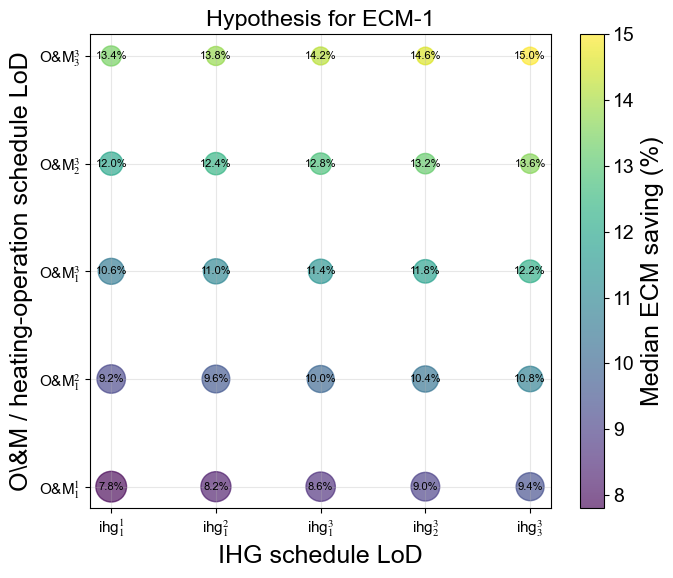

In [29]:
plot_ecm_lod_design_space(
    df=lod_hypothesis_df,
    ecm_name="ECM-1: Heating setpoint change",
    ihg_lods=ihg_lods,
    om_lods=om_lods,
    title="Hypothesis for ECM-1",
)

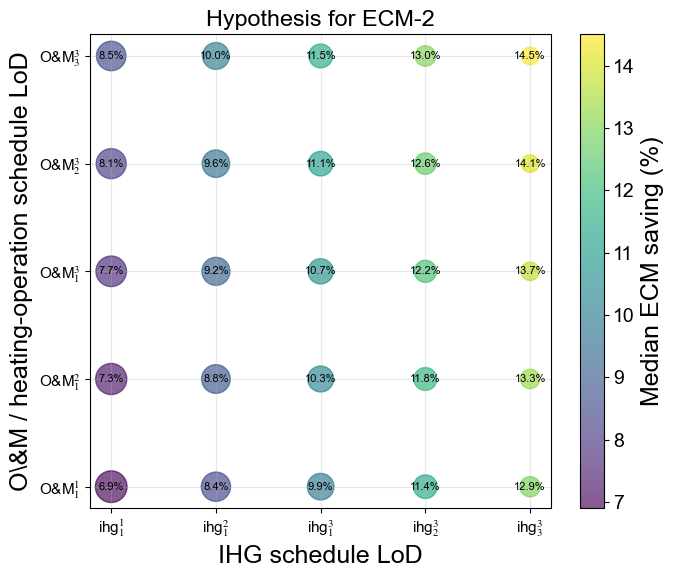

In [28]:
plot_ecm_lod_design_space(
    df=lod_hypothesis_df,
    ecm_name="ECM-2: Occupancy-based ventilation control",
    ihg_lods=ihg_lods,
    om_lods=om_lods,
    title="Hypothesis for ECM-2",
)